In [1]:
import pandas as pd
from transformers import pipeline
from tqdm import tqdm
import pandas as pd
import numpy as np
 
np.random.seed(42)

d:\ribkaadevina\college\8.S2\3. SEM 3\Thesis\Playground\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os

# --- UPDATE THIS PATH IF YOUR DATASET FOLDER IS ELSEWHERE ---
DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"

#load dataset
file_path = os.path.join(OUTPUT_DIR, "dataset_with_sentiment.xlsx")
df = pd.read_excel(file_path)

Jumlah data: (5715, 18)


,tweet_id,display_name,username,followers,tweet,created_at,lang,user_location,tweet_location,likes,retweets,replies,mentions,reply_to_username,tweet_clean,region,location_clean,city_clean
0,1406970754688717056,Яizal do,afrkml,350301,Gejala yg ditimbulkan memang umum dan sudah di...,Mon Jun 21 13:42:22 +0000 2021,in,Dukung kami di sini →,NaN,245,44,4,NaN,afrkml,gejala yg ditimbulkan memang umum dan sudah di...,dukung kami di sini →,dukung kami di sini,NaN
1,1409518162362568960,🍒,claudiaars__,230,Until this minute masih ga habis pikir bisa2ny...,Mon Jun 28 14:24:52 +0000 2021,in,Jakarta,NaN,0,0,1,NaN,NaN,until this minute masih ga habis pikir bisanya...,jakarta,jakarta,jakarta
2,1408483130994946048,R30_K03 🇮🇩,ryuuken86,24,Hari jum'at 24 juni. Guru SMP ku meninggal di ...,Fri Jun 25 17:52:01 +0000 2021,in,Indonesia,NaN,0,0,0,NaN,NaN,hari jumat juni guru smp ku meninggal di rs kr...,indonesia,indonesia,NaN
3,1409494375294390016,M Taufik Zoelkifli,emtezet,2127,Singapura sudah akan beranjak dari Pandemi men...,Mon Jun 28 12:50:20 +0000 2021,in,Jakarta,"Cempaka Putih, Indonesia",2,2,0,NaN,NaN,singapura sudah akan beranjak dari pandemi men...,"cempaka putih, indonesia",cempaka putih indonesia,NaN
4,1407938212631237120,rahardjoguyub,guyubrahardjo,598,@CNNIndonesia @PutraWadapi Kondisi jakarta yg ...,Thu Jun 24 05:46:42 +0000 2021,in,"DKI Jakarta, Indonesia",NaN,0,0,0,"CNNIndonesia, PutraWadapi",cnnindonesia,kondisi jakarta yg mendung dan hujan menambah ...,"dki jakarta, indonesia",dki jakarta indonesia,jakarta


Comparison

Model 1

In [28]:
# Load pretrained model 1
model1 = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    tokenizer="w11wo/indonesian-roberta-base-sentiment-classifier"
)

tqdm.pandas()

# Prediction function
def predict_roberta(text):

    result = model1(str(text)[:512])[0]

    label = result["label"]
    confidence = result["score"]

    # convert to signed polarity
    if label == "positive":
        polarity = confidence

    elif label == "negative":
        polarity = -confidence

    else:
        polarity = 0.0

    return pd.Series([
        label,
        confidence,
        polarity
    ])

# Apply model
df[[
    "sentiment_roberta",
    "confidence_roberta",
    "polarity_roberta"
]] = df["tweet_clean"].progress_apply(
    predict_roberta
)

100%|██████████| 5715/5715 [13:11<00:00,  7.22it/s]


Model 2

In [29]:
# Load pretrained model 2
from transformers import pipeline

model2 = pipeline(
    "sentiment-analysis",
    model="taufiqdp/indonesian-sentiment",
    tokenizer="taufiqdp/indonesian-sentiment"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 864.32it/s]


In [30]:
def predict_model2(text):

    result = model2(str(text)[:512])[0]

    # normalize labels
    label_map = {
        "positif": "positive",
        "negatif": "negative",
        "netral": "neutral"
    }

    label = label_map[result["label"]]

    confidence = result["score"]

    # signed polarity
    if label == "positive":
        polarity = confidence

    elif label == "negative":
        polarity = -confidence

    else:
        polarity = 0.0

    return pd.Series([
        label,
        confidence,
        polarity
    ])

In [31]:
df[[
    "sentiment_model2",
    "confidence_model2",
    "polarity_model2"
]] = df["tweet_clean"].progress_apply(
    predict_model2
)

100%|██████████| 5715/5715 [10:30<00:00,  9.06it/s]


In [32]:
df.head()

,tweet_id,display_name,username,followers,tweet,created_at,lang,user_location,tweet_location,likes,...,tweet_clean,region,location_clean,city_clean,sentiment_roberta,confidence_roberta,polarity_roberta,sentiment_model2,confidence_model2,polarity_model2
0,1406970754688717056,Яizal do,afrkml,350301,Gejala yg ditimbulkan memang umum dan sudah di...,Mon Jun 21 13:42:22 +0000 2021,in,Dukung kami di sini →,NaN,245,...,gejala yg ditimbulkan memang umum dan sudah di...,dukung kami di sini →,dukung kami di sini,NaN,negative,0.752307,-0.752307,negative,0.995110,-0.995110
1,1409518162362568960,🍒,claudiaars__,230,Until this minute masih ga habis pikir bisa2ny...,Mon Jun 28 14:24:52 +0000 2021,in,Jakarta,NaN,0,...,until this minute masih ga habis pikir bisanya...,jakarta,jakarta,jakarta,negative,0.996685,-0.996685,negative,0.619597,-0.619597
2,1408483130994946048,R30_K03 🇮🇩,ryuuken86,24,Hari jum'at 24 juni. Guru SMP ku meninggal di ...,Fri Jun 25 17:52:01 +0000 2021,in,Indonesia,NaN,0,...,hari jumat juni guru smp ku meninggal di rs kr...,indonesia,indonesia,NaN,negative,0.616726,-0.616726,positive,0.891653,0.891653
3,1409494375294390016,M Taufik Zoelkifli,emtezet,2127,Singapura sudah akan beranjak dari Pandemi men...,Mon Jun 28 12:50:20 +0000 2021,in,Jakarta,"Cempaka Putih, Indonesia",2,...,singapura sudah akan beranjak dari pandemi men...,"cempaka putih, indonesia",cempaka putih indonesia,NaN,positive,0.778616,0.778616,positive,0.954192,0.954192
4,1407938212631237120,rahardjoguyub,guyubrahardjo,598,@CNNIndonesia @PutraWadapi Kondisi jakarta yg ...,Thu Jun 24 05:46:42 +0000 2021,in,"DKI Jakarta, Indonesia",NaN,0,...,kondisi jakarta yg mendung dan hujan menambah ...,"dki jakarta, indonesia",dki jakarta indonesia,jakarta,neutral,0.654501,0.000000,neutral,0.889500,0.000000


In [34]:
df.head()

,tweet_id,display_name,username,followers,tweet,created_at,lang,user_location,tweet_location,likes,...,tweet_clean,region,location_clean,city_clean,sentiment_roberta,confidence_roberta,polarity_roberta,sentiment_model2,confidence_model2,polarity_model2
0,1406970754688717056,Яizal do,afrkml,350301,Gejala yg ditimbulkan memang umum dan sudah di...,Mon Jun 21 13:42:22 +0000 2021,in,Dukung kami di sini →,NaN,245,...,gejala yg ditimbulkan memang umum dan sudah di...,dukung kami di sini →,dukung kami di sini,NaN,negative,0.752307,-0.752307,negative,0.995110,-0.995110
1,1409518162362568960,🍒,claudiaars__,230,Until this minute masih ga habis pikir bisa2ny...,Mon Jun 28 14:24:52 +0000 2021,in,Jakarta,NaN,0,...,until this minute masih ga habis pikir bisanya...,jakarta,jakarta,jakarta,negative,0.996685,-0.996685,negative,0.619597,-0.619597
2,1408483130994946048,R30_K03 🇮🇩,ryuuken86,24,Hari jum'at 24 juni. Guru SMP ku meninggal di ...,Fri Jun 25 17:52:01 +0000 2021,in,Indonesia,NaN,0,...,hari jumat juni guru smp ku meninggal di rs kr...,indonesia,indonesia,NaN,negative,0.616726,-0.616726,positive,0.891653,0.891653
3,1409494375294390016,M Taufik Zoelkifli,emtezet,2127,Singapura sudah akan beranjak dari Pandemi men...,Mon Jun 28 12:50:20 +0000 2021,in,Jakarta,"Cempaka Putih, Indonesia",2,...,singapura sudah akan beranjak dari pandemi men...,"cempaka putih, indonesia",cempaka putih indonesia,NaN,positive,0.778616,0.778616,positive,0.954192,0.954192
4,1407938212631237120,rahardjoguyub,guyubrahardjo,598,@CNNIndonesia @PutraWadapi Kondisi jakarta yg ...,Thu Jun 24 05:46:42 +0000 2021,in,"DKI Jakarta, Indonesia",NaN,0,...,kondisi jakarta yg mendung dan hujan menambah ...,"dki jakarta, indonesia",dki jakarta indonesia,jakarta,neutral,0.654501,0.000000,neutral,0.889500,0.000000


Comparison

In [35]:
comparison = pd.DataFrame({
    "RoBERTa": df["sentiment_roberta"].value_counts(),
    "IndoBERT": df["sentiment_model2"].value_counts()
}).fillna(0)

print(comparison)

          RoBERTa  IndoBERT
neutral      4162      3728
negative     1148      1161
positive      405       826


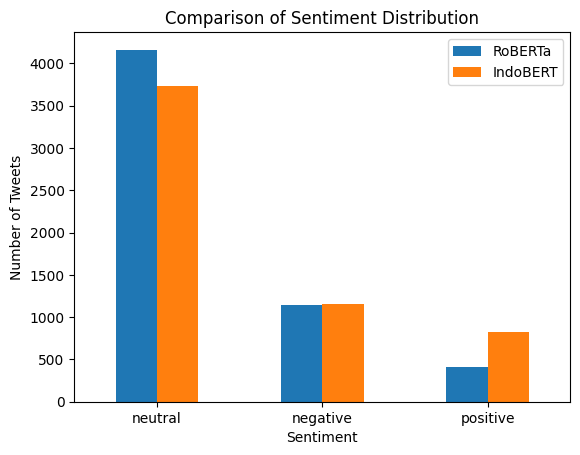

In [36]:
import matplotlib.pyplot as plt

comparison.plot(kind="bar")

plt.title("Comparison of Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.xticks(rotation=0)

plt.show()

In [37]:
agreement = (
    df["sentiment_roberta"]
    ==
    df["sentiment_model2"]
).mean()

print(
    "Agreement Rate:",
    round(agreement * 100, 2),
    "%"
)

Agreement Rate: 78.81 %


In [38]:
print(
    "Average RoBERTa Confidence:",
    round(df["confidence_roberta"].mean(), 4)
)

print(
    "Average IndoBERT Confidence:",
    round(df["confidence_model2"].mean(), 4)
)

Average RoBERTa Confidence: 0.8792
Average IndoBERT Confidence: 0.8929


In [39]:
# choose final model

df["sentiment"] = df["sentiment_model2"]

df["sentiment_score"] = df["polarity_model2"]

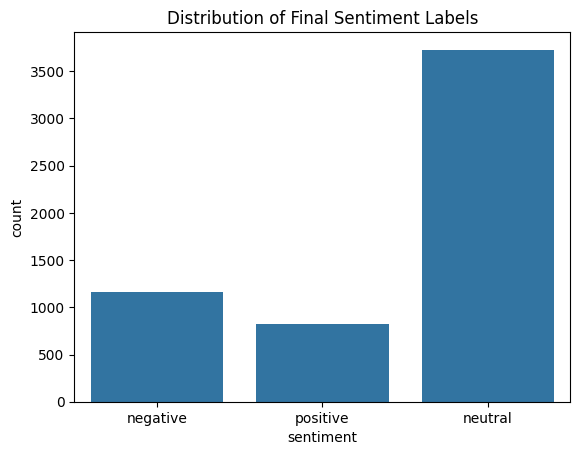

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="sentiment",
    data=df,
    order=[
        "positive",
        "neutral",
        "negative"
    ],
    palette={
        "positive": "#2ECC71",
        "neutral": "#BDBDBD",
        "negative": "#E74C3C"
    }
)

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=10
    )

plt.title(
    "Distribution of Final Sentiment Labels",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
output_path = os.path.join(OUTPUT_DIR, "dataset_with_sentiment.xlsx")

df.to_excel(
    output_path,
    index=False
)

print("Dataset saved:")
print(output_path)

Dataset saved:
D:\ribkaadevina\college\8.S2\3. SEM 3\Thesis\Playground\dataset_with_sentiment.xlsx


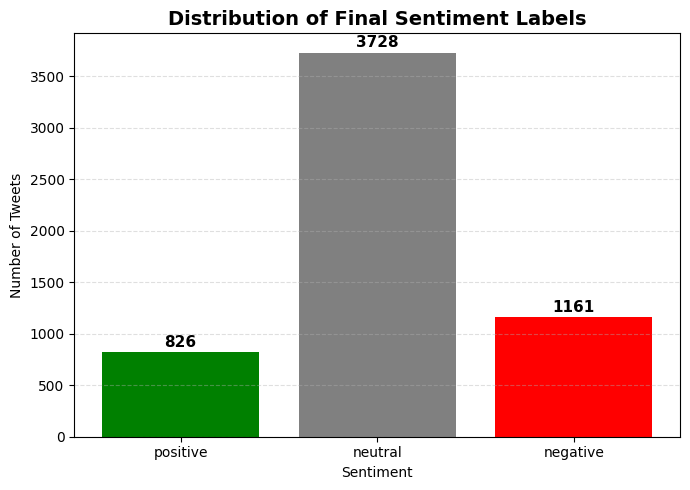

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file_path = r"D:\ribkaadevina\college\8.S2\3. SEM 3\Thesis\Playground\dataset_with_sentiment.xlsx"
df = pd.read_excel(file_path)

# Hitung distribusi sentimen
sentiment_counts = (
    df["sentiment"]
    .value_counts()
    .reindex(["positive", "neutral", "negative"])
)

# Warna sesuai sentimen
colors = ["green", "gray", "red"]

# Plot
plt.figure(figsize=(7,5))
bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=colors
)

# Tambahkan label angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Distribution of Final Sentiment Labels", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Model 3

In [ ]:
from transformers import pipeline
from tqdm import tqdm
import pandas as pd

final = pd.read_excel(os.path.join(OUTPUT_DIR, 'annotation_sample_final.xlsx'))

In [1]:
from transformers import pipeline

model3 = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)
print("Model loaded successfully")

d:\ribkaadevina\college\8.S2\3. SEM 3\Thesis\Playground\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 24853.49it/s]


Model loaded successfully


d:\ribkaadevina\college\8.S2\3. SEM 3\Thesis\Playground\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--cardiffnlp--twitter-xlm-roberta-base-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [2]:
def predict_xlmr(text):
    result = model3(str(text)[:512])[0]
    label_map = {
        "positive": "positive",
        "negative": "negative",
        "neutral": "neutral"
    }
    label = label_map.get(result["label"].lower(), "neutral")
    confidence = result["score"]
    return pd.Series([label, confidence])

In [ ]:
tqdm.pandas()
final[["sentiment_xlmr", "confidence_xlmr"]] = final["tweet_clean"].progress_apply(predict_xlmr)

final.to_excel(os.path.join(OUTPUT_DIR, 'annotation_sample_final_with_xlmr.xlsx'), index=False)
print("Done, saved to annotation_sample_final_with_xlmr.xlsx")

100%|██████████| 374/374 [00:46<00:00,  8.13it/s]


Done, saved to annotation_sample_final_with_xlmr.xlsx


Model 4

In [7]:
from transformers import pipeline
from tqdm import tqdm
import pandas as pd

model4 = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    tokenizer="nlptown/bert-base-multilingual-uncased-sentiment"
)
print("Model loaded successfully")

d:\ribkaadevina\college\8.S2\3. SEM 3\Thesis\Playground\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--nlptown--bert-base-multilingual-uncased-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2524.9

Model loaded successfully


In [8]:
def predict_mbert(text):
    result = model4(str(text)[:512])[0]
    stars = int(result["label"][0])  # extracts the leading digit, e.g. "1 star" -> 1
    confidence = result["score"]
    
    # Map 5-star rating to 3-class sentiment
    if stars <= 2:
        label = "negative"
    elif stars == 3:
        label = "neutral"
    else:
        label = "positive"
    return pd.Series([label, confidence])

In [ ]:
tqdm.pandas()
final[["sentiment_mbert", "confidence_mbert"]] = final["tweet_clean"].progress_apply(predict_mbert)

final.to_excel(os.path.join(OUTPUT_DIR, 'annotation_sample_final_with_mbert.xlsx'), index=False)
print("Done")

100%|██████████| 374/374 [00:45<00:00,  8.16it/s]


Done


Model 5

In [11]:
from transformers import pipeline
from tqdm import tqdm
import pandas as pd

model5 = pipeline(
    "sentiment-analysis",
    model="ayameRushia/roberta-base-indonesian-sentiment-analysis-smsa",
    tokenizer="ayameRushia/roberta-base-indonesian-sentiment-analysis-smsa"
)

print("Model loaded successfully")

d:\ribkaadevina\college\8.S2\3. SEM 3\Thesis\Playground\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--ayameRushia--roberta-base-indonesian-sentiment-analysis-smsa. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00

Model loaded successfully


In [12]:
def predict_indoroberta2(text):
    result = model5(str(text)[:512])[0]
    label_map = {
        "positive": "positive",
        "negative": "negative",
        "neutral": "neutral",
        # add numeric mappings here if the sanity check shows LABEL_0/1/2 format instead
    }
    label = label_map.get(result["label"].lower(), "neutral")
    confidence = result["score"]
    return pd.Series([label, confidence])

In [ ]:
tqdm.pandas()
final[["sentiment_indoroberta2", "confidence_indoroberta2"]] = final["tweet_clean"].progress_apply(predict_indoroberta2)
final.to_excel(os.path.join(OUTPUT_DIR, 'annotation_sample_final_with_indoroberta2.xlsx'), index=False)

100%|██████████| 374/374 [00:47<00:00,  7.86it/s]


Model 6

In [ ]:
from transformers import pipeline
from tqdm import tqdm
import pandas as pd

final = pd.read_excel(os.path.join(OUTPUT_DIR, 'annotation_sample_final.xlsx'))

model7 = pipeline(
    "sentiment-analysis",
    model="Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis",
    tokenizer="Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis"
)
print("Model loaded successfully")

d:\ribkaadevina\college\8.S2\3. SEM 3\Thesis\Playground\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--Aardiiiiy--indobertweet-base-Indonesian-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:0

Model loaded successfully


In [8]:
# Sanity check first
print(model7("saya sakit demam berdarah, sangat menderita")[0])

{'label': 'Negative', 'score': 0.978937566280365}


In [ ]:
def predict_indobertweet2024(text):
    result = model7(str(text)[:512])[0]
    label = result["label"].lower()  # 'Negative' -> 'negative'
    confidence = result["score"]
    return pd.Series([label, confidence])

tqdm.pandas()
final[["sentiment_indobertweet2024", "confidence_indobertweet2024"]] = final["tweet_clean"].progress_apply(predict_indobertweet2024)

final.to_excel(os.path.join(OUTPUT_DIR, 'annotation_sample_final_with_indobertweet2024.xlsx'), index=False)
print("Done, saved to annotation_sample_final_with_indobertweet2024.xlsx")

100%|██████████| 374/374 [00:42<00:00,  8.90it/s]


Done, saved to annotation_sample_final_with_indobertweet2024.xlsx


Evaluation

In [ ]:
import pandas as pd

final = pd.read_excel(os.path.join(OUTPUT_DIR, 'annotation_sample_final.xlsx'))
reference = pd.read_excel(os.path.join(OUTPUT_DIR, 'reference_model_predictions_random.xlsx'))

eval_df = final[['tweet_id', 'final_label']].merge(reference, on='tweet_id', how='left')

print("Merged rows:", len(eval_df))
print("Missing predictions after merge:", eval_df[['sentiment_roberta', 'sentiment_model2']].isna().sum())

Merged rows: 374
Missing predictions after merge: sentiment_roberta    0
sentiment_model2     0
dtype: int64


In [2]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

labels_order = ['negative', 'neutral', 'positive']

print("=== RoBERTa (sentiment_roberta) vs. Ground Truth ===")
print("Accuracy:", accuracy_score(eval_df['final_label'], eval_df['sentiment_roberta']))
print(classification_report(eval_df['final_label'], eval_df['sentiment_roberta'], labels=labels_order, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(eval_df['final_label'], eval_df['sentiment_roberta'], labels=labels_order))

print("\n=== IndoBERT/model2 (sentiment_model2) vs. Ground Truth — YOUR FINAL MODEL ===")
print("Accuracy:", accuracy_score(eval_df['final_label'], eval_df['sentiment_model2']))
print(classification_report(eval_df['final_label'], eval_df['sentiment_model2'], labels=labels_order, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(eval_df['final_label'], eval_df['sentiment_model2'], labels=labels_order))

=== RoBERTa (sentiment_roberta) vs. Ground Truth ===
Accuracy: 0.7406417112299465
              precision    recall  f1-score   support

    negative     0.3846    0.6977    0.4959        43
     neutral     0.8603    0.8182    0.8387       286
    positive     0.5417    0.2889    0.3768        45

    accuracy                         0.7406       374
   macro avg     0.5955    0.6016    0.5705       374
weighted avg     0.7673    0.7406    0.7437       374

Confusion Matrix:
[[ 30  11   2]
 [ 43 234   9]
 [  5  27  13]]

=== IndoBERT/model2 (sentiment_model2) vs. Ground Truth — YOUR FINAL MODEL ===
Accuracy: 0.732620320855615
              precision    recall  f1-score   support

    negative     0.4394    0.6744    0.5321        43
     neutral     0.8916    0.7762    0.8299       286
    positive     0.3898    0.5111    0.4423        45

    accuracy                         0.7326       374
   macro avg     0.5736    0.6539    0.6014       374
weighted avg     0.7792    0.7326    0.

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

labels_order = ['negative', 'neutral', 'positive']

print("=== XLM-R (cardiffnlp) vs. Ground Truth ===")
print("Accuracy:", accuracy_score(final['final_label'], final['sentiment_xlmr']))
print(classification_report(final['final_label'], final['sentiment_xlmr'], labels=labels_order, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(final['final_label'], final['sentiment_xlmr'], labels=labels_order))

=== XLM-R (cardiffnlp) vs. Ground Truth ===
Accuracy: 0.4037433155080214
              precision    recall  f1-score   support

    negative     0.1754    0.9302    0.2952        43
     neutral     0.8584    0.3392    0.4862       286
    positive     0.4242    0.3111    0.3590        45

    accuracy                         0.4037       374
   macro avg     0.4860    0.5268    0.3801       374
weighted avg     0.7276    0.4037    0.4489       374

Confusion Matrix:
[[ 40   2   1]
 [171  97  18]
 [ 17  14  14]]


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

labels_order = ['negative', 'neutral', 'positive']

print("=== mBERT (nlptown) vs. Ground Truth ===")
print("Accuracy:", accuracy_score(final['final_label'], final['sentiment_mbert']))
print(classification_report(final['final_label'], final['sentiment_mbert'], labels=labels_order, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(final['final_label'], final['sentiment_mbert'], labels=labels_order))

=== mBERT (nlptown) vs. Ground Truth ===
Accuracy: 0.21122994652406418
              precision    recall  f1-score   support

    negative     0.1535    0.8605    0.2606        43
     neutral     0.7027    0.0909    0.1610       286
    positive     0.1667    0.3556    0.2270        45

    accuracy                         0.2112       374
   macro avg     0.3410    0.4356    0.2162       374
weighted avg     0.5751    0.2112    0.1804       374

Confusion Matrix:
[[ 37   4   2]
 [182  26  78]
 [ 22   7  16]]


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

labels_order = ['negative', 'neutral', 'positive']

print("=== IndoRoBERTa-SmSA (ayameRushia) vs. Ground Truth ===")
print("Accuracy:", accuracy_score(final['final_label'], final['sentiment_indoroberta2']))
print(classification_report(final['final_label'], final['sentiment_indoroberta2'], labels=labels_order, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(final['final_label'], final['sentiment_indoroberta2'], labels=labels_order))

=== IndoRoBERTa-SmSA (ayameRushia) vs. Ground Truth ===
Accuracy: 0.6951871657754011
              precision    recall  f1-score   support

    negative     0.3692    0.5581    0.4444        43
     neutral     0.8494    0.7692    0.8073       286
    positive     0.3200    0.3556    0.3368        45

    accuracy                         0.6952       374
   macro avg     0.5129    0.5610    0.5295       374
weighted avg     0.7305    0.6952    0.7090       374

Confusion Matrix:
[[ 24  15   4]
 [ 36 220  30]
 [  5  24  16]]


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

labels_order = ['negative', 'neutral', 'positive']

print("=== IndoBertweet 2024 (Aardiiiiy) vs. Ground Truth ===")
print("Accuracy:", accuracy_score(final['final_label'], final['sentiment_indobertweet2024']))
print(classification_report(final['final_label'], final['sentiment_indobertweet2024'], labels=labels_order, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(final['final_label'], final['sentiment_indobertweet2024'], labels=labels_order))

=== IndoBertweet 2024 (Aardiiiiy) vs. Ground Truth ===
Accuracy: 0.679144385026738
              precision    recall  f1-score   support

    negative     0.3125    0.8140    0.4516        43
     neutral     0.8419    0.7448    0.7904       286
    positive     0.6667    0.1333    0.2222        45

    accuracy                         0.6791       374
   macro avg     0.6070    0.5640    0.4881       374
weighted avg     0.7599    0.6791    0.6830       374

Confusion Matrix:
[[ 35   8   0]
 [ 70 213   3]
 [  7  32   6]]


Calibration Analysis

In [12]:
print(reference.columns.tolist())

['tweet_id', 'tweet_clean', 'sentiment_roberta', 'sentiment_model2', 'sentiment']


In [ ]:
full_dataset = pd.read_excel(os.path.join(OUTPUT_DIR, 'dataset_with_sentiment.xlsx'))

# Merge in just the confidence column for the 374 sampled tweets
eval_df = final[['tweet_id', 'final_label']].merge(reference, on='tweet_id', how='left')
eval_df = eval_df.merge(
    full_dataset[['tweet_id', 'confidence_model2']],
    on='tweet_id',
    how='left'
)

print(eval_df['confidence_model2'].isna().sum())  # should be 0 if the merge worked
print(eval_df.columns.tolist())

0
['tweet_id', 'final_label', 'tweet_clean', 'sentiment_roberta', 'sentiment_model2', 'sentiment', 'confidence_model2']


In [15]:
eval_df['correct'] = (eval_df['final_label'] == eval_df['sentiment_model2'])

eval_df['confidence_bin'] = pd.cut(
    eval_df['confidence_model2'],
    bins=[0, 0.6, 0.75, 0.9, 1.0],
    labels=['0.50-0.60', '0.60-0.75', '0.75-0.90', '0.90-1.00']
)

calibration = eval_df.groupby('confidence_bin', observed=True)['correct'].agg(['mean', 'count'])
calibration.columns = ['accuracy', 'n_tweets']
calibration['accuracy'] = (calibration['accuracy'] * 100).round(2)

print(calibration)
print()
print("Overall mean confidence:", eval_df['confidence_model2'].mean().round(4))
print("Overall accuracy:", (eval_df['correct'].mean() * 100).round(2), "%")

                accuracy  n_tweets
confidence_bin                    
0.50-0.60          76.19        21
0.60-0.75          43.59        39
0.75-0.90          57.41        54
0.90-1.00          80.77       260

Overall mean confidence: 0.892
Overall accuracy: 73.26 %


Error scan

In [ ]:
misclassified = eval_df[eval_df['correct'] == False][['tweet_clean', 'final_label', 'sentiment_model2']]
print(f"Total misclassified: {len(misclassified)} of {len(eval_df)}")
misclassified.to_excel(os.path.join(OUTPUT_DIR, 'misclassified_for_review.xlsx'), index=False)

Total misclassified: 100 of 374


In [17]:
import sys
print(sys.version)

3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


In [18]:
import transformers
import torch
print("transformers:", transformers.__version__)
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


transformers: 5.6.0
torch: 2.11.0+cpu
CUDA available: False
